## **Advanced Machine Learning (Assignment 2, Problem 1)**
---
---

Università degli Studi Milano Bicocca \
CdLM Informatica — A.A 2025/2026

---
---

#### **Componenti del gruppo:**
— Oleksandra Golub (856706)

---
---

Link al dataset che ho utilizzato: [Fashion MNIST dataset](https://keras.io/api/datasets/fashion_mnist/)

---
---


In [4]:
from google.colab import drive
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist

os.environ["TF_DETERMINISTIC_OPS"]="1"
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

In [5]:
# Monta Google Drive
drive.mount('/content/drive')

# Path della cartella
drive_folder = '/content/drive/MyDrive/Assignment 2 AML/problem 1'

# Verifica cartella
print(f"\nCartella: {drive_folder}")
print(f"Esiste? {os.path.exists(drive_folder)}")

if os.path.exists(drive_folder):
    print("\nFile disponibili:")
    for file in os.listdir(drive_folder):
        print(f"  - {file}")

    # Copia file con shutil (più affidabile)
    print("\nCopia file in corso...")
    files_to_copy = {
        'problem_one.weights.h5': 'problem_one.weights.h5',
        'Problem 1_accuracy.png': 'original_accuracy.png',
        'Problem 1_loss.png': 'original_loss.png',
        'problem_one (2).png': 'architecture.png'
    }

    for source_name, dest_name in files_to_copy.items():
        source = os.path.join(drive_folder, source_name)
        if os.path.exists(source):
            shutil.copy2(source, dest_name)
            print(f" {source_name} → {dest_name}")
        else:
            print(f" {source_name} non trovato")

Mounted at /content/drive

Cartella: /content/drive/MyDrive/Assignment 2 AML/problem 1
Esiste? True

File disponibili:
  - problem_one (2).png
  - problem_one.weights.h5
  - Problem 1_accuracy.png
  - Problem 1_loss.png
  - codice + report

Copia file in corso...
 problem_one.weights.h5 → problem_one.weights.h5
 Problem 1_accuracy.png → original_accuracy.png
 Problem 1_loss.png → original_loss.png
 problem_one (2).png → architecture.png


In [6]:
# 1. CARICAMENTO DATASET
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. PREPROCESSING
# Normalizzazione pixel values [0, 255] → [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten 28x28 → 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print(f"Training set: {x_train.shape} con labels: {y_train.shape}")
print(f"Test set: {x_test.shape} con labels: {y_test.shape}")

# Nomi delle classi Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set: (60000, 784) con labels: (60000,)
Test set: (10000, 784) con labels: (10000,)


In [7]:
# 3. RICOSTRUZIONE DELL'ARCHITETTURA ORIGINALE
def create_model():
    """
    Architettura basata sull'immagine problem_one (2).png:
    Input (784) -> Dense(512) -> Dense(128) -> Dense(64) -> Dense(10)
    """
    model = keras.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,), name='layer-one'),
        layers.Dense(128, activation='relu', name='layer-two'),
        layers.Dense(64, activation='relu', name='layer-three'),
        layers.Dense(10, activation='softmax', name='layer-four')
    ])
    return model

model_architecture = create_model()
model_architecture.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer-one (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer-two (Dense)               │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer-three (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer-four (Dense)              │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,490 (1.82 MB)

 Trainable params: 476,490 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 4. CARICAMENTO DEL MODELLO PROBLEMATICO CON I PESI FORNITI
model_problematic = create_model()

# Compilamento con gli stessi parametri usati per il training
model_problematic.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Caricamento dei pesi
try:
    model_problematic.load_weights('problem_one.weights.h5')
    print("Pesi caricati con successo!")
except Exception as e:
    print(f"Errore nel caricamento dei pesi: {e}")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Pesi caricati con successo!


In [9]:
# 5. VALUTAZIONE DEL MODELLO PROBLEMATICO
train_loss_prob, train_acc_prob = model_problematic.evaluate(
    x_train, y_train, verbose=0, batch_size=128
)
test_loss_prob, test_acc_prob = model_problematic.evaluate(
    x_test, y_test, verbose=0, batch_size=128
)

print(f"\n Risultati del modello problematico (lr=0.1):")
print(f"  Training Accuracy: {train_acc_prob:.4f} ({train_acc_prob*100:.2f}%)")
print(f"  Training Loss: {train_loss_prob:.4f}")
print(f"  Validation Accuracy:{test_acc_prob:.4f} ({test_acc_prob*100:.2f}%)")
print(f"  Validation Loss: {test_loss_prob:.4f}")

# Analisi predizioni
print("\n Analisi predizioni su 1000 samples:")
sample_size = 1000
predictions = model_problematic.predict(x_test[:sample_size], verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test[:sample_size]

correct = np.sum(predicted_classes == true_classes)
print(f"  Accuracy: {correct}/{sample_size} = {correct/sample_size:.2%}")

# Distribuzione predizioni
print("\n Distribuzione delle predizioni:")
for i in range(10):
    count = np.sum(predicted_classes == i)
    print(f" Classe {i} ({class_names[i]:12s}): {count:3d} ({count/sample_size:5.1%})")

# Check se è vicino a random (10% per classe)
print(f"\n Random baseline accuracy: 10% (1 classe su 10)")
print(f" Performance attuale: {test_acc_prob*100:.1f}%")
if test_acc_prob < 0.3:
    print("\n Il modello performa quasi a livello random! (divergenza)")
elif test_acc_prob < 0.5:
    print("\n Il modello performa male (possibile divergenza parziale)")
else:
    print("\n Il modello apprende qualcosa, ma c'è spazio per miglioramenti")


 Risultati del modello problematico (lr=0.1):
  Training Accuracy: 0.1988 (19.88%)
  Training Loss: 1.8045
  Validation Accuracy:0.1992 (19.92%)
  Validation Loss: 1.8061

 Analisi predizioni su 1000 samples:
  Accuracy: 207/1000 = 20.70%

 Distribuzione delle predizioni:
 Classe 0 (T-shirt/top ):   0 ( 0.0%)
 Classe 1 (Trouser     ):   0 ( 0.0%)
 Classe 2 (Pullover    ): 742 (74.2%)
 Classe 3 (Dress       ):   0 ( 0.0%)
 Classe 4 (Coat        ):   0 ( 0.0%)
 Classe 5 (Sandal      ):   1 ( 0.1%)
 Classe 6 (Shirt       ):   0 ( 0.0%)
 Classe 7 (Sneaker     ): 257 (25.7%)
 Classe 8 (Bag         ):   0 ( 0.0%)
 Classe 9 (Ankle boot  ):   0 ( 0.0%)

 Random baseline accuracy: 10% (1 classe su 10)
 Performance attuale: 19.9%

 Il modello performa quasi a livello random! (divergenza)


In [10]:
# STEP 6: TRAINING MODELLO CORRETTO

model_fixed = create_model()
model_fixed.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fixed = model_fixed.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7681 - loss: 0.6739 - val_accuracy: 0.8526 - val_loss: 0.4112
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8643 - loss: 0.3759 - val_accuracy: 0.8633 - val_loss: 0.3735
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8785 - loss: 0.3288 - val_accuracy: 0.8670 - val_loss: 0.3654
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8877 - loss: 0.3014 - val_accuracy: 0.8656 - val_loss: 0.3658
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8950 - loss: 0.2804 - val_accuracy: 0.8705 - val_loss: 0.3607
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9008 - loss: 0.2638 - val_accuracy: 0.8689 - val_loss: 0.3725
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9054 - loss: 0.2495 - val_accuracy: 0.8753 - val_loss: 0.3555
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9104 - loss: 0.2371 - val_ac

In [11]:
# STEP 7: CONFRONTO RISULTATI

train_acc_fixed = history_fixed.history['accuracy'][-1]
val_acc_fixed = history_fixed.history['val_accuracy'][-1]
train_loss_fixed = history_fixed.history['loss'][-1]
val_loss_fixed = history_fixed.history['val_loss'][-1]

print(" MODELLO PROBLEMATICO (lr=0.1, pesi forniti)")
print(f"  Training Accuracy:   {train_acc_prob:.4f} ({train_acc_prob*100:.2f}%)")
print(f"  Validation Accuracy: {test_acc_prob:.4f} ({test_acc_prob*100:.2f}%)")
print(f"  Training Loss:       {train_loss_prob:.4f}")
print(f"  Validation Loss:     {test_loss_prob:.4f}")

print("\n MODELLO CORRETTO (lr=0.001, trainato da zero)")
print(f"  Training Accuracy:   {train_acc_fixed:.4f} ({train_acc_fixed*100:.2f}%)")
print(f"  Validation Accuracy: {val_acc_fixed:.4f} ({val_acc_fixed*100:.2f}%)")
print(f"  Training Loss:       {train_loss_fixed:.4f}")
print(f"  Validation Loss:     {val_loss_fixed:.4f}")

print("\n MIGLIORAMENTO")
acc_improvement = val_acc_fixed - test_acc_prob
loss_improvement = test_loss_prob - val_loss_fixed
acc_percentage = (acc_improvement / test_acc_prob * 100) if test_acc_prob > 0 else 0

print(f"  Validation Accuracy: {acc_improvement:+.4f} ({acc_percentage:+.1f}%)")
print(f"  Validation Loss:     {loss_improvement:+.4f}")

if acc_improvement > 0.3:
    print("\n Il problema era chiaramente il learning rate!")
elif acc_improvement > 0.1:
    print("\n  Il learning rate era un problema significativo!")
else:
    print("\n  Miglioramento limitato. Potrebbero esserci altri problemi.")

 MODELLO PROBLEMATICO (lr=0.1, pesi forniti)
  Training Accuracy:   0.1988 (19.88%)
  Validation Accuracy: 0.1992 (19.92%)
  Training Loss:       1.8045
  Validation Loss:     1.8061

 MODELLO CORRETTO (lr=0.001, trainato da zero)
  Training Accuracy:   0.9175 (91.75%)
  Validation Accuracy: 0.8792 (87.92%)
  Training Loss:       0.2188
  Validation Loss:     0.3650

 MIGLIORAMENTO
  Validation Accuracy: +0.6800 (+341.4%)
  Validation Loss:     +1.4411

 Il problema era chiaramente il learning rate!


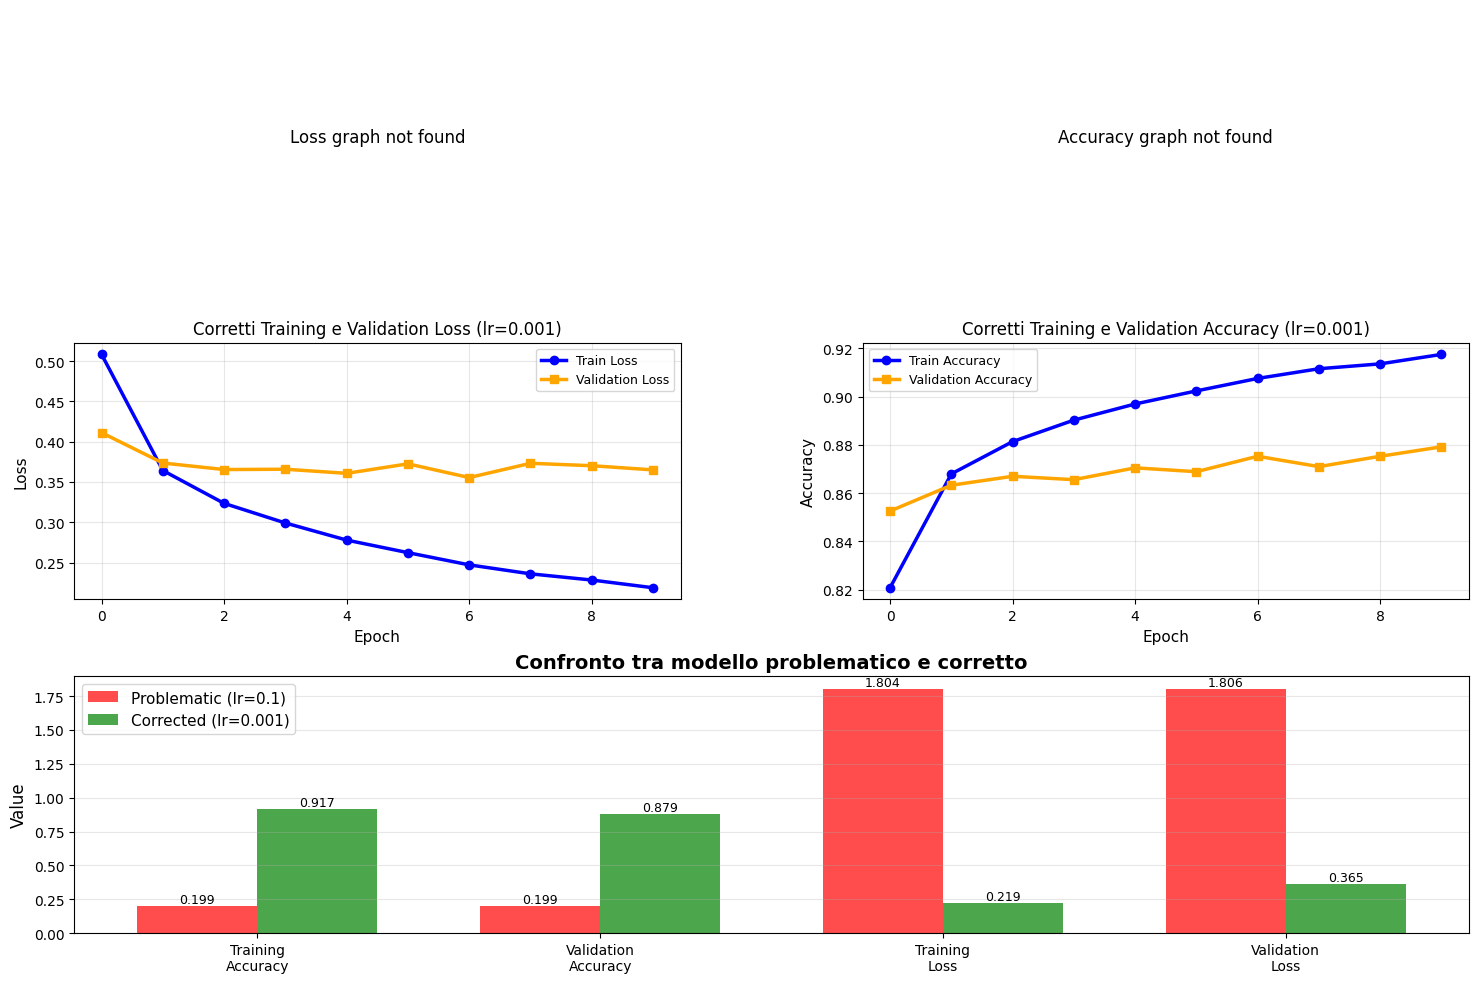

In [12]:
# STEP 7: VISUALIZZAZIONE

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# riga dei grafici originali
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

try:
    img_loss = plt.imread('Problem 1_loss.png')
    ax1.imshow(img_loss)
    ax1.axis('off')
    ax1.set_title('Original Problematic Model Loss (lr=0.1)', fontsize=12)
except:
    ax1.text(0.5, 0.5, 'Loss graph not found', ha='center', va='center', fontsize=12)
    ax1.axis('off')

try:
    img_acc = plt.imread('Problem 1_accuracy.png')
    ax2.imshow(img_acc)
    ax2.axis('off')
    ax2.set_title('Original Problematic Model Accuracy (lr=0.1)', fontsize=12)
except:
    ax2.text(0.5, 0.5, 'Accuracy graph not found', ha='center', va='center', fontsize=12)
    ax2.axis('off')

# riga dei grafici del modello corretto (loss)
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(history_fixed.history['loss'],
         label='Train Loss', linewidth=2.5, marker='o', markersize=6, color='blue')
ax3.plot(history_fixed.history['val_loss'],
         label='Validation Loss', linewidth=2.5, marker='s', markersize=6, color='orange')
ax3.set_title('Corretti Training e Validation Loss (lr=0.001)', fontsize=12)
ax3.set_xlabel('Epoch', fontsize=11)
ax3.set_ylabel('Loss', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# riga dei grafici del modello corretto (accuracy)
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(history_fixed.history['accuracy'],
         label='Train Accuracy', linewidth=2.5, marker='o', markersize=6, color='blue')
ax4.plot(history_fixed.history['val_accuracy'],
         label='Validation Accuracy', linewidth=2.5, marker='s', markersize=6, color='orange')
ax4.set_title('Corretti Training e Validation Accuracy (lr=0.001)', fontsize=12)
ax4.set_xlabel('Epoch', fontsize=11)
ax4.set_ylabel('Accuracy', fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# confronto finale
ax5 = fig.add_subplot(gs[2, :])
categories = ['Training\nAccuracy', 'Validation\nAccuracy', 'Training\nLoss', 'Validation\nLoss']
problematic_values = [train_acc_prob, test_acc_prob, train_loss_prob, test_loss_prob]
fixed_values = [train_acc_fixed, val_acc_fixed, train_loss_fixed, val_loss_fixed]

x = np.arange(len(categories))
width = 0.35

bars1 = ax5.bar(x - width/2, problematic_values, width, label='Problematic (lr=0.1)',
                color='red', alpha=0.7)
bars2 = ax5.bar(x + width/2, fixed_values, width, label='Corrected (lr=0.001)',
                color='green', alpha=0.7)

ax5.set_ylabel('Value', fontsize=12)
ax5.set_title('Confronto tra modello problematico e corretto',
              fontsize=14, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(categories, fontsize=10)
ax5.legend(fontsize=11)
ax5.grid(True, alpha=0.3, axis='y')

# Aggiungi valori sopra le barre
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)
plt.show()